In [1]:
from metpy.calc import dewpoint_from_relative_humidity, downdraft_cape
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from ecape.calc import calc_ecape
import metpy.calc as mpcalc
from metpy.calc import dewpoint_from_relative_humidity, most_unstable_cape_cin, lfc, lcl, bulk_shear, wind_components, el, parcel_profile, precipitable_water
from metpy.calc import k_index, lifted_index, mixed_parcel, parcel_profile
from metpy.units import units
import metpy.constants as mpconsts
from numpy import concatenate
from datetime import date
today = date.today()

#### Plot settings: 
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['mathtext.fontset'] = 'cm'
rcParams['mathtext.rm'] = 'serif'
mpl.rcParams["figure.dpi"] = 350
plt.rcParams['hatch.linewidth'] = 0.35


In [2]:
### CTRL Data:
data_ctrl = pd.read_csv('/glade/u/home/mfranke/work/PhD/Exp1_Reviews/NewCESM2/CTRL_InputSounding.csv', header = None)
data_ctrl = data_ctrl.replace('NaN', 0).fillna(0)
data_ctrl = data_ctrl.iloc[1:].reset_index(drop = True).astype(float)

### Constant RH Data: 
data_crh = pd.read_csv('/glade/u/home/mfranke/work/CM1/casper/derecho_comp/cm1r21.1/cm1.runs/Soundings/input_sounding_constantRH',
                      sep = '\s+', header = None, names =  ['pressure', 'theta', 'qv', 'u', 'v'])

### Constant RH Data: 
data_lens = pd.read_csv('/glade/u/home/mfranke/work/CM1/casper/derecho_comp/cm1r21.1/cm1.runs/Soundings/input_sounding_ensMean100',
                      sep = '\s+', header = None, names =  ['pressure', 'theta', 'qv', 'u', 'v'])

### Ensemble Data: 
base_path = '/glade/u/home/mfranke/work/CM1/cm1r21.1/cm1.runs/CESM_100mems/Soundings/'
ensembles = {
    f'ens{i}': pd.read_csv(f'{base_path}input_sounding_{i:03d}', sep = '\s+', header = None,
                           names = ['pressure', 'theta', 'qv', 'u', 'v'])
    for i in range(1, 101)}

### Primary constants: 

In [3]:
p0 = 1000 * units('hPa')
u = data_ctrl.iloc[:,3].values * units('m/s')
v = data_ctrl.iloc[:,4].values * units('m/s')
heights = data_ctrl.iloc[:,0].replace(1000,2).values * units('meters')    # single bracket → (N,)
pressure_levels = mpcalc.height_to_pressure_std(heights).squeeze()
pressure_levels.magnitude[0] = 1000


### Set up CTRL: 

In [4]:
ctrl_theta = data_ctrl.iloc[:,1].values * units('K')
ctrl_q = (data_ctrl.iloc[:,2].values / 1000)* units('kg/kg')
ctrl_q_g = data_ctrl.iloc[:,2].values * units('g/kg')
ctrl_tempK = mpcalc.temperature_from_potential_temperature(pressure_levels, ctrl_theta)
ctrl_tempC = (ctrl_tempK.magnitude - 273.15) * units('degC')


### Set up CRH: 

In [5]:
crh_theta = data_crh.iloc[:,1].values * units('K')
crh_q = (data_crh.iloc[:,2].values / 1000)* units('kg/kg')
crh_q_g = data_crh.iloc[:,2].values * units('g/kg')
crh_tempK = mpcalc.temperature_from_potential_temperature(pressure_levels, crh_theta)
crh_tempC = (crh_tempK.magnitude - 273.15) * units('degC')

lens_theta = data_lens.iloc[:,1].values * units('K')
lens_q = (data_lens.iloc[:,2].values / 1000)* units('kg/kg')
lens_q_g = data_lens.iloc[:,2].values * units('g/kg')
lens_tempK = mpcalc.temperature_from_potential_temperature(pressure_levels, lens_theta)
lens_tempC = (lens_tempK.magnitude - 273.15) * units('degC')

### Set up the ensembles:

In [6]:
### Theta for all ensembles:
ens_theta = {
    key: (df.iloc[:,1].values * units('K'))
    for key, df in ensembles.items()}

### Mixing ratio (kg/kg) for all ensembles:
ens_q = {
    key: ((df.iloc[:,2].values /1000) * units('kg/kg'))
    for key, df in ensembles.items()}

### Mixing ratio (g/kg) for all ensembles:
ens_q_g = {
    key: (df.iloc[:,2].values * units('g/kg'))
    for key, df in ensembles.items()}

### Temperature (K) for all ensembles: 
ens_tempK = {
    key: mpcalc.temperature_from_potential_temperature(pressure_levels, theta)
    for key, theta in ens_theta.items()}

### Temperature (C) for all ensembles: 
ens_tempC = {
    key: (tempK.magnitude - 273.15) * units('degC')
    for key, tempK in ens_tempK.items()}

### Set up the ensemble mean: 

In [7]:
ens_tempC_mean = np.mean([ens_tempC[key] for key in ens_tempC.keys()], axis=0) * units('degC')

### ECAPE: 

In [8]:
### For ctrl:
ctrl_ecape = calc_ecape(heights, pressure_levels, ctrl_tempC, ctrl_q, u, v)

### For 100 members: 
ens_ecape = {
    key: calc_ecape(heights, pressure_levels, ens_tempC[key], ens_q[key], u, v)
    for key in ens_tempC.keys()}

### For ensemble mean: 
ens_ecape_mean = np.mean([ens_ecape[key].magnitude for key in ens_ecape.keys()], axis = 0) 

###------------------- Percent Change: 
### For 100 members: 
percent_ecape_mems = {}
for mem, values in ens_ecape.items():
    percent_ecape_mems[mem] = ((values.magnitude - ctrl_ecape.magnitude) / ctrl_ecape.magnitude) * 100

### For ensemble mean: 
percent_ecape_mean = ((ens_ecape_mean - ctrl_ecape.magnitude) / ctrl_ecape.magnitude) * 100

In [9]:
### For CRH and LENS:
crh_ecape = calc_ecape(heights, pressure_levels, crh_tempC, crh_q, u, v)
lens_ecape = calc_ecape(heights, pressure_levels, lens_tempC, lens_q, u, v)

###------------------- Percent Change: 
percent_ecape_crh = ((crh_ecape.magnitude - ctrl_ecape.magnitude) / ctrl_ecape.magnitude) * 100 
percent_ecape_lens = ((lens_ecape.magnitude - ctrl_ecape.magnitude) / ctrl_ecape.magnitude) * 100 

print(percent_ecape_lens)

23.941157003414737


## Relative Humidity: 

In [10]:
### For ctrl:
ctrl_rh = mpcalc.relative_humidity_from_mixing_ratio(pressure_levels, ctrl_tempC, ctrl_q)

### For 100 members: 
ens_rh = {
    key: mpcalc.relative_humidity_from_mixing_ratio(pressure_levels, ens_tempC[key], ens_q[key])
    for key in ens_tempC.keys()}

### For ensemble mean: 
ens_rh_mean = np.mean([ens_rh[key] for key in ens_rh.keys()], axis = 0) 

###------------------- Percent Change: 
### For 100 members: 
percent_rh_mems = {}
for mem, values in ens_rh.items():
    percent_rh_mems[mem] = ((values - ctrl_rh) / ctrl_rh) * 100

### For ensemble mean: 
percent_rh_mean = ((ens_rh_mean - ctrl_rh) / ctrl_rh) * 100
print(percent_rh_mean[23])

-8.897987786869578 dimensionless


In [11]:
### For CRH and LENS:
crh_rh = mpcalc.relative_humidity_from_mixing_ratio(pressure_levels, crh_tempC, crh_q)
lens_rh = mpcalc.relative_humidity_from_mixing_ratio(pressure_levels, lens_tempC, lens_q)

###------------------- Percent Change: 
percent_rh_crh = ((crh_rh - ctrl_rh) / ctrl_rh) * 100
percent_rh_lens = ((lens_rh - ctrl_rh) / ctrl_rh) * 100

print(percent_rh_lens[23])

-8.898053604687334 dimensionless


## Dewpoint:

In [12]:
### For ctrl:
ctrl_dewC = mpcalc.dewpoint_from_relative_humidity(ctrl_tempC, ctrl_rh)

### For 100 members: 
ens_dewC = {
    key: mpcalc.dewpoint_from_relative_humidity(ens_tempC[key], ens_rh[key])
    for key in ens_tempC.keys()}

### For ensemble mean: 
ens_dewC_mean = np.mean([ens_dewC[key] for key in ens_dewC.keys()], axis = 0) * units('degC')

###------------------- Percent Change: 
### For 100 members: 
percent_dewC_mems = {}
for mem, values in ens_dewC.items():
    percent_dewC_mems[mem] = ((values - ctrl_dewC) / ctrl_dewC) * 100

### For ensemble mean: 
percent_dewC_mean = ((ens_dewC_mean - ctrl_dewC) / ctrl_dewC) * 100

print(percent_dewC_mean[11])

0.7164452913340901 delta_degree_Celsius / kelvin


/glade/derecho/scratch/mfranke/tmp/ipykernel_83056/2583339153.py:2: UserWarning: Relative humidity >120%, ensure proper units.
  ctrl_dewC = mpcalc.dewpoint_from_relative_humidity(ctrl_tempC, ctrl_rh)
/glade/derecho/scratch/mfranke/tmp/ipykernel_83056/2583339153.py:6: UserWarning: Relative humidity >120%, ensure proper units.
  key: mpcalc.dewpoint_from_relative_humidity(ens_tempC[key], ens_rh[key])


In [13]:
### For crh and lens:
crh_dewC = mpcalc.dewpoint_from_relative_humidity(crh_tempC, crh_rh)
lens_dewC = mpcalc.dewpoint_from_relative_humidity(lens_tempC, lens_rh)

###------------------- Percent Change: 
percent_dewC_crh = ((crh_dewC - ctrl_dewC) / ctrl_dewC) * 100
percent_dewC_lens = ((lens_dewC - ctrl_dewC) / ctrl_dewC) * 100

print(percent_dewC_lens[11])

0.716490503925675 delta_degree_Celsius / kelvin


/glade/derecho/scratch/mfranke/tmp/ipykernel_83056/513924252.py:2: UserWarning: Relative humidity >120%, ensure proper units.
  crh_dewC = mpcalc.dewpoint_from_relative_humidity(crh_tempC, crh_rh)
/glade/derecho/scratch/mfranke/tmp/ipykernel_83056/513924252.py:3: UserWarning: Relative humidity >120%, ensure proper units.
  lens_dewC = mpcalc.dewpoint_from_relative_humidity(lens_tempC, lens_rh)


## Precipitable Water

In [14]:
### For ctrl:
ctrl_pwat = mpcalc.precipitable_water(pressure_levels, ctrl_dewC)

### For 100 members: 
ens_pwat = {
    key: mpcalc.precipitable_water(pressure_levels, ens_dewC[key])
    for key in ens_dewC.keys()}

### For ensemble mean: 
ens_pwat_mean = np.mean([ens_pwat[key].magnitude for key in ens_pwat.keys()], axis = 0) 

###------------------- Percent Change: 
### For 100 members: 
percent_pwat_mems = {}
for mem, values in ens_pwat.items():
    percent_pwat_mems[mem] = ((values - ctrl_pwat) / ctrl_pwat) * 100

### For ensemble mean: 
percent_pwat_mean = ((ens_pwat_mean- ctrl_pwat.magnitude) / ctrl_pwat.magnitude) * 100

print(percent_pwat_mean)

14.962399166600408


In [15]:
### For crh and lens:
crh_pwat = mpcalc.precipitable_water(pressure_levels, crh_dewC)
lens_pwat = mpcalc.precipitable_water(pressure_levels, lens_dewC)

###------------------- Percent Change: 
percent_pwat_crh = ((crh_pwat.magnitude - ctrl_pwat.magnitude) / ctrl_pwat.magnitude) * 100
percent_pwat_lens = ((lens_pwat.magnitude - ctrl_pwat.magnitude) / ctrl_pwat.magnitude) * 100

print(percent_pwat_lens)

14.962403257096616


## Mixed Layer CAPE and CIN: 

In [16]:
pressure_levels = pressure_levels.squeeze()

###-------------------- GET THE MIXED LAYER: 
# 1. Get the mixed layer parcels (temp and dewpoint)
# 2. Get the mixed layer lcl
# 3. Compute the mixed layer depth

### For CTRL:
ml_temperature_ctrl, ml_dewpoint_ctrl = mpcalc.mixed_layer(pressure_levels, ctrl_tempC.squeeze(), ctrl_dewC.squeeze(), depth=100 * units.hPa) 
ml_lcl_pressure_ctrl, ml_lcl_temperature_ctrl = mpcalc.lcl(pressure_levels[0], ml_temperature_ctrl, ml_dewpoint_ctrl)
ml_depth_ctrl = pressure_levels[0] - ml_lcl_pressure_ctrl

### For 100 members: 
ens_ml = {
    key: mpcalc.mixed_layer(pressure_levels, ens_tempC[key].squeeze(), ens_dewC[key].squeeze(), depth=100 * units.hPa)
    for key in ens_tempC.keys()}
ens_ml_temperature = {key: val[0] for key, val in ens_ml.items()}
ens_ml_dewpoint    = {key: val[1] for key, val in ens_ml.items()}

ens_ml_lcl = {
    key: mpcalc.lcl(pressure_levels[0], ens_ml_temperature[key], ens_ml_dewpoint[key])
    for key in ens_ml_temperature.keys()}
ens_lcl_pressure = {key: val[0] for key, val in ens_ml_lcl.items()}
ens_lcl_temperature = {key: val[1] for key, val in ens_ml_lcl.items()}
ens_ml_depth = {key: pressure_levels[0] - ens_lcl_pressure[key] for key in ens_lcl_pressure.keys()}

### For ensemble mean: 
ml_temperature, ml_dewpoint = mpcalc.mixed_layer(pressure_levels, ens_tempC_mean.squeeze(), ens_dewC_mean.squeeze(), depth=100 * units.hPa)
ml_lcl_pressure, ml_lcl_temperature = mpcalc.lcl(pressure_levels[0], ml_temperature, ml_dewpoint)
ens_ml_depth_mean = pressure_levels[0] - ml_lcl_pressure



In [17]:
###------------------------- Now, use the mixed layer to find the ML CAPE and CIN: 
### For CTRL:
ml_cape_cin_ctrl = mpcalc.mixed_layer_cape_cin(pressure_levels, ctrl_tempC.squeeze(), ctrl_dewC.squeeze(), depth = ml_depth_ctrl.magnitude * units.hPa)
ctrl_cape = ml_cape_cin_ctrl[0]
ctrl_cin = ml_cape_cin_ctrl[1]

### For 100 members: 
ens_ml_cape_cin = {
    key: mpcalc.mixed_layer_cape_cin(pressure_levels, ens_tempC[key].squeeze(), ens_dewC[key].squeeze(), depth = ens_ml_depth[key].magnitude * units.hPa)
    for key in ens_tempC.keys()}
ens_ml_cape = {key: val[0] for key, val in ens_ml_cape_cin.items()}
ens_ml_cin = {key: val[1] for key, val in ens_ml_cape_cin.items()}

### For ensemble mean: 
ml_cape_cin_mean = mpcalc.mixed_layer_cape_cin(pressure_levels, ens_tempC_mean.squeeze(), ens_dewC_mean.squeeze(), depth=ens_ml_depth_mean.magnitude * units.hPa)
ens_cape_mean = ml_cape_cin_mean[0]
ens_cin_mean = ml_cape_cin_mean[1]

###------------------- Percent Change: 
###### CAPE:
### For 100 members: 
percent_cape_mems = {}
for mem, values in ens_ml_cape.items():
    percent_cape_mems[mem] = ((values - ctrl_cape) / ctrl_cape) * 100

### For ensemble mean: 
percent_cape_mean = ((ens_cape_mean - ctrl_cape) / ctrl_cape) * 100

###### CIN:
### For 100 members: 
percent_cin_mems = {}
for mem, values in ens_ml_cin.items():
    percent_cin_mems[mem] = ((values - ctrl_cin) / ctrl_cin) * 100

### For ensemble mean: 
percent_cin_mean = ((ens_cin_mean - ctrl_cin) / ctrl_cin) * 100


In [18]:
### For crh and lens:
ml_temperature_crh, ml_dewpoint_crh = mpcalc.mixed_layer(pressure_levels, crh_tempC.squeeze(), crh_dewC.squeeze(), depth=100 * units.hPa) 
ml_lcl_pressure_crh, ml_lcl_temperature_crh = mpcalc.lcl(pressure_levels[0], ml_temperature_crh, ml_dewpoint_crh)
ml_depth_crh = pressure_levels[0] - ml_lcl_pressure_crh

ml_temperature_lens, ml_dewpoint_lens = mpcalc.mixed_layer(pressure_levels, lens_tempC.squeeze(), lens_dewC.squeeze(), depth=100 * units.hPa) 
ml_lcl_pressure_lens, ml_lcl_temperature_lens = mpcalc.lcl(pressure_levels[0], ml_temperature_lens, ml_dewpoint_lens)
ml_depth_lens = pressure_levels[0] - ml_lcl_pressure_lens


In [19]:
### For crh and lens:
ml_cape_cin_crh = mpcalc.mixed_layer_cape_cin(pressure_levels, crh_tempC.squeeze(), crh_dewC.squeeze(), depth = ml_depth_crh.magnitude * units.hPa)
crh_cape = ml_cape_cin_crh[0]
crh_cin = ml_cape_cin_crh[1]

ml_cape_cin_lens = mpcalc.mixed_layer_cape_cin(pressure_levels, lens_tempC.squeeze(), lens_dewC.squeeze(), depth = ml_depth_lens.magnitude * units.hPa)
lens_cape = ml_cape_cin_lens[0]
lens_cin = ml_cape_cin_lens[1]

###------------------- Percent Change: 
percent_cin_crh = ((crh_cin - ctrl_cin) / ctrl_cin) * 100
percent_cin_lens = ((lens_cin - ctrl_cin) / ctrl_cin) * 100

percent_cape_crh = ((crh_cape - ctrl_cape) / ctrl_cape) * 100
percent_cape_lens = ((lens_cape - ctrl_cape) / ctrl_cape) * 100


## LCL: 

In [20]:
### For CTRL: 
ctrl_lcl = mpcalc.lcl(pressure_levels, ctrl_tempC, ctrl_dewC)
ctrl_lcl_pressure = ctrl_lcl[0][0]
ctrl_lcl_height = mpcalc.pressure_to_height_std(ctrl_lcl_pressure).to(units.km)

### For 100 members:
ens_lcl = {
    key: mpcalc.lcl(pressure_levels, ens_tempC[key], ens_dewC[key])
    for key in ens_tempC.keys()}
ens_lcl_pressure = {key: val[0][0] for key, val in ens_lcl.items()}
ens_lcl_height = {
    key: mpcalc.pressure_to_height_std(ens_lcl_pressure[key]).to(units.km)
    for key in ens_lcl_pressure.keys()}

### For ensemble mean: 
ens_lcl_height_mean = np.mean([ens_lcl_height[key].magnitude for key in ens_lcl_height.keys()], axis=0) * units('km')

###------------------- Percent Change: 
### For 100 members: 
percent_lcl_mems = {}
for mem, values in ens_lcl_height.items():
    percent_lcl_mems[mem] = ((values - ctrl_lcl_height) / ctrl_lcl_height) * 100

### For ensemble mean: 
percent_lcl_mean = ((ens_lcl_height_mean - ctrl_lcl_height) / ctrl_lcl_height) * 100

In [21]:
### For crh and lens: 
crh_lcl = mpcalc.lcl(pressure_levels, crh_tempC, crh_dewC)
crh_lcl_pressure = crh_lcl[0][0]
crh_lcl_height = mpcalc.pressure_to_height_std(crh_lcl_pressure).to(units.km)

lens_lcl = mpcalc.lcl(pressure_levels, lens_tempC, lens_dewC)
lens_lcl_pressure = lens_lcl[0][0]
lens_lcl_height = mpcalc.pressure_to_height_std(lens_lcl_pressure).to(units.km)

###------------------- Percent Change: 
percent_lcl_crh = ((crh_lcl_height - ctrl_lcl_height) / ctrl_lcl_height) * 100
percent_lcl_lens = ((lens_lcl_height - ctrl_lcl_height) / ctrl_lcl_height) * 100


### Freezing Level: 

In [22]:
### This will interpolate to closest freezing level: 
def get_frz_height(tempC, pressure_levels):
    temp = tempC.magnitude.squeeze()
    pres = pressure_levels.magnitude.squeeze()
    frz_pressure = np.interp(0, temp[::-1], pres[::-1]) * units('hPa')
    return mpcalc.pressure_to_height_std(frz_pressure).to(units.km)

In [23]:
ctrl_frz_height = get_frz_height(ctrl_tempC, pressure_levels)
crh_frz_height  = get_frz_height(crh_tempC,  pressure_levels)
lens_frz_height = get_frz_height(lens_tempC, pressure_levels)

print(lens_frz_height)

4.157988588930687 kilometer


In [24]:
### For CTRL:
ctrl_frz_height = get_frz_height(ctrl_tempC, pressure_levels)

### For 100 members: 
ens_frz_height = {
    key: get_frz_height(ens_tempC[key], pressure_levels)
    for key in ens_tempC.keys()}

### For ensemble mean: 
ens_frz_level_height_mean = np.mean([v.magnitude for v in ens_frz_height.values()]) * units('km')
print(ens_frz_level_height_mean)

###------------------- Percent Change: 
### For 100 members: 
percent_frz_mems = {
    mem: ((values - ctrl_frz_height) / ctrl_frz_height) * 100
    for mem, values in ens_frz_height.items()}

### For ensemble mean: 
percent_frz_mean = ((ens_frz_level_height_mean - ctrl_frz_height) / ctrl_frz_height) * 100


4.1579854036289134 kilometer


In [25]:
print(percent_frz_mean)

13.590879618606733 dimensionless


In [26]:
### For crh and lens: 
crh_frz_height  = get_frz_height(crh_tempC,  pressure_levels)
lens_frz_height = get_frz_height(lens_tempC, pressure_levels)

###------------------- Percent Change: 
percent_frz_crh  = ((crh_frz_height  - ctrl_frz_height) / ctrl_frz_height) * 100
percent_frz_lens = ((lens_frz_height - ctrl_frz_height) / ctrl_frz_height) * 100


## WCD: 

In [27]:
### For CTRL: 
ctrl_wcd = ctrl_frz_height - ctrl_lcl_height 

### For 100 members: 
ens_wcd = {key: ens_frz_height[key] - ens_lcl_height[key] for key in ens_frz_height.keys()}

### For ensemble mean: 
ens_wcd_mean = np.mean([v.magnitude for v in ens_wcd.values()]) * units('km')

###------------------- Percent Change: 
### For 100 members: 
percent_wcd_mems = {}
for mem, values in ens_wcd.items():
    percent_wcd_mems[mem] = ((values - ctrl_wcd) / ctrl_wcd) * 100

### For ensemble mean: 
percent_wcd_mean = ((ens_wcd_mean - ctrl_wcd) / ctrl_wcd) * 100

print(percent_wcd_mean)

6.563304857693169 dimensionless


In [28]:
### For crh and lens: 
crh_wcd = crh_frz_height - crh_lcl_height 
lens_wcd = lens_frz_height - lens_lcl_height 

###------------------- Percent Change: 
percent_wcd_crh = ((crh_wcd - ctrl_wcd) / ctrl_wcd) * 100
percent_wcd_lens = ((lens_wcd - ctrl_wcd) / ctrl_wcd) * 100

print(percent_wcd_lens)

6.564221331012068 dimensionless


## DCAPE: 

In [29]:
### For CTRL:
ctrl_dcape = mpcalc.downdraft_cape(pressure_levels, ctrl_tempC, ctrl_dewC)[0]

### For 100 members: 
ens_dcape_calc = {
    key: mpcalc.downdraft_cape(pressure_levels, ens_tempC[key], ens_dewC[key])
    for key in ens_tempC.keys()}
ens_dcape = {key: val[0] for key, val in ens_dcape_calc.items()}

### For ensemble mean: 
ens_dcape_mean = np.mean([v.magnitude for v in ens_dcape.values()]) * units('J/kg')

###------------------- Percent Change: 
### For 100 members: 
percent_dcape_mems = {}
for mem, values in ens_dcape.items():
    percent_dcape_mems[mem] = ((values - ctrl_dcape) / ctrl_dcape) * 100

### For ensemble mean: 
percent_dcape_mean = ((ens_dcape_mean - ctrl_dcape) / ctrl_dcape) * 100

print(percent_dcape_mean)

35.5784727607331 dimensionless


In [30]:
### For crh and lens:
crh_dcape = mpcalc.downdraft_cape(pressure_levels, crh_tempC, crh_dewC)[0]
lens_dcape = mpcalc.downdraft_cape(pressure_levels, lens_tempC, lens_dewC)[0]

###------------------- Percent Change: 
percent_dcape_crh = ((crh_dcape - ctrl_dcape) / ctrl_dcape) * 100
percent_dcape_lens = ((lens_dcape - ctrl_dcape) / ctrl_dcape) * 100

print(percent_dcape_lens)

35.62396833090269 dimensionless


## LFC:

In [31]:
### FOR CTRL:
ctrl_lfc_pressure = mpcalc.lfc(pressure_levels, ctrl_tempC, ctrl_dewC)[0]
ctrl_lfc_height = mpcalc.pressure_to_height_std(ctrl_lfc_pressure).to(units.km)

### For 100 members: 
ens_lfc = {
    key: mpcalc.lfc(pressure_levels, ens_tempC[key], ens_dewC[key])
    for key in ens_tempC.keys()}
ens_lfc_pressure = {key: val[0] for key, val in ens_lfc.items()}
ens_lfc_height = {
    key: mpcalc.pressure_to_height_std(ens_lfc_pressure[key]).to(units.km)
    for key in ens_lfc_pressure.keys()}

### For ensemble mean: 
ens_lfc_height_mean = np.mean([v.magnitude for v in ens_lfc_height.values()]) * units('km')

###------------------- Percent Change: 
### For 100 members: 
percent_lfc_mems = {
    mem: ((values - ctrl_lfc_height) / ctrl_lfc_height) * 100
    for mem, values in ens_lfc_height.items()}

### For ensemble mean: 
percent_lfc_mean = ((ens_lfc_height_mean - ctrl_lfc_height) / ctrl_lfc_height) * 100

print(percent_lfc_mean)

14.421825575490962 dimensionless


In [32]:
### FOR crh and lens:
crh_lfc_pressure = mpcalc.lfc(pressure_levels, crh_tempC, crh_dewC)[0]
crh_lfc_height = mpcalc.pressure_to_height_std(crh_lfc_pressure).to(units.km)

lens_lfc_pressure = mpcalc.lfc(pressure_levels, lens_tempC, lens_dewC)[0]
lens_lfc_height = mpcalc.pressure_to_height_std(lens_lfc_pressure).to(units.km)

###------------------- Percent Change: 
percent_lfc_crh = ((crh_lfc_height - ctrl_lfc_height) / ctrl_lfc_height) * 100
percent_lfc_lens = ((lens_lfc_height - ctrl_lfc_height) / ctrl_lfc_height) * 100

print(percent_lfc_lens)

14.415932755443354 dimensionless


## KI

In [33]:
### For CTRL:
ctrl_ki = mpcalc.k_index(pressure_levels, ctrl_tempC, ctrl_dewC)

### For 100 members: 
ens_ki = {
    key: mpcalc.k_index(pressure_levels, ens_tempC[key], ens_dewC[key])
    for key in ens_tempC.keys()}

### For ensemble mean: 
ens_ki_mean = np.mean([v.magnitude for v in ens_ki.values()]) * units('degC')

###------------------- Percent Change: 
### For 100 members: 
percent_ki_mems = {
    mem: ((values - ctrl_ki) / ctrl_ki) * 100
    for mem, values in ens_ki.items()}

### For ensemble mean: 
percent_ki_mean = ((ens_ki_mean - ctrl_ki) / ctrl_ki) * 100 

print(percent_ki_mean)

0.13458157047113492 delta_degree_Celsius / kelvin


In [34]:
### For crh and lens:
crh_ki = mpcalc.k_index(pressure_levels, crh_tempC, crh_dewC)
lens_ki = mpcalc.k_index(pressure_levels, lens_tempC, lens_dewC)

###------------------- Percent Change: 
percent_ki_crh = ((crh_ki - ctrl_ki) / ctrl_ki) * 100 
percent_ki_lens = ((lens_ki - ctrl_ki) / ctrl_ki) * 100 

print(percent_ki_lens)

0.1346747932366081 delta_degree_Celsius / kelvin


## LI

In [35]:
###------------------ LI needs mixed parcel and the parcel profile first: 
###-------- FOR CTRL: 
### Calculate 500m mixed parcel:
parcel_p_ctrl, parcel_t_ctrl, parcel_td_ctrl = mixed_parcel(pressure_levels, ctrl_tempC, ctrl_dewC, depth = 500 * units.m, height = heights) 

### Replace sounding temp/pressure in lowest 500m with mixed values
above_ctrl = heights > 500 * units.m
press_ctrl = concatenate([[parcel_p_ctrl], pressure_levels[above_ctrl]])
temp_ctrl = concatenate([[parcel_t_ctrl], ctrl_tempC[above_ctrl]])

### Calculate parcel profile from out new mixed parcel: 
mixed_prof_ctrl = parcel_profile(press_ctrl, parcel_t_ctrl, parcel_td_ctrl)

### Caculcate the LI using our mixed profile: 
ctrl_li = mpcalc.lifted_index(press_ctrl, temp_ctrl, mixed_prof_ctrl).magnitude


In [36]:
###------------------ LI needs mixed parcel and the parcel profile first: 
###-------- FOR 100mems: 
### Calculate 500m mixed parcel:
ens_li = {}
for key in ens_tempC.keys():
    # Mixed parcel for this member
    parcel_p, parcel_t, parcel_td = mixed_parcel(
        pressure_levels, ens_tempC[key], ens_dewC[key],
        depth=500 * units.m, height=heights)

    # Replace lowest 500m with mixed parcel values
    above = heights > 500 * units.m
    press_mem = concatenate([[parcel_p], pressure_levels[above]])
    temp_mem  = concatenate([[parcel_t], ens_tempC[key][above]])

    # Parcel profile and LI
    mixed_prof = parcel_profile(press_mem, parcel_t, parcel_td)
    ens_li[key] = mpcalc.lifted_index(press_mem, temp_mem, mixed_prof).magnitude

###-------- ENSEMBLE MEAN:
ens_li_mean = np.mean([v for v in ens_li.values()])# * units('dimensionless')

###-------- PERCENT CHANGE FROM CTRL:
### For 100 members:
percent_li_mems = {
    mem: ((values - ctrl_li) / ctrl_li) * 100
    for mem, values in ens_li.items()}

### For ensemble mean:
percent_li_mean = ((ens_li_mean - ctrl_li) / ctrl_li) * 100


In [37]:
### For CRH: 
###------------------ LI needs mixed parcel and the parcel profile first: 
### Calculate 500m mixed parcel:
parcel_p_crh, parcel_t_crh, parcel_td_crh = mixed_parcel(pressure_levels, crh_tempC, crh_dewC, depth = 500 * units.m, height = heights) 

### Replace sounding temp/pressure in lowest 500m with mixed values
above_crh = heights > 500 * units.m
press_crh = concatenate([[parcel_p_crh], pressure_levels[above_crh]])
temp_crh = concatenate([[parcel_t_crh], crh_tempC[above_crh]])

### Calculate parcel profile from out new mixed parcel: 
mixed_prof_crh = parcel_profile(press_crh, parcel_t_crh, parcel_td_crh)

### Caculcate the LI using our mixed profile: 
crh_li = mpcalc.lifted_index(press_crh, temp_crh, mixed_prof_crh).magnitude

###-------- PERCENT CHANGE FROM CTRL:
percent_li_crh = ((crh_li - ctrl_li) / ctrl_li) * 100


In [38]:
### For LENS: 
###------------------ LI needs mixed parcel and the parcel profile first: 
### Calculate 500m mixed parcel:
parcel_p_lens, parcel_t_lens, parcel_td_lens = mixed_parcel(pressure_levels, lens_tempC, lens_dewC, depth = 500 * units.m, height = heights) 

### Replace sounding temp/pressure in lowest 500m with mixed values
above_lens = heights > 500 * units.m
press_lens = concatenate([[parcel_p_lens], pressure_levels[above_lens]])
temp_lens = concatenate([[parcel_t_lens], lens_tempC[above_lens]])

### Calculate parcel profile from out new mixed parcel: 
mixed_prof_lens = parcel_profile(press_lens, parcel_t_lens, parcel_td_lens)

### Caculcate the LI using our mixed profile: 
lens_li = mpcalc.lifted_index(press_lens, temp_lens, mixed_prof_lens).magnitude

###-------- PERCENT CHANGE FROM CTRL:
percent_li_lens = ((lens_li - ctrl_li) / ctrl_li) * 100


# Plotting:

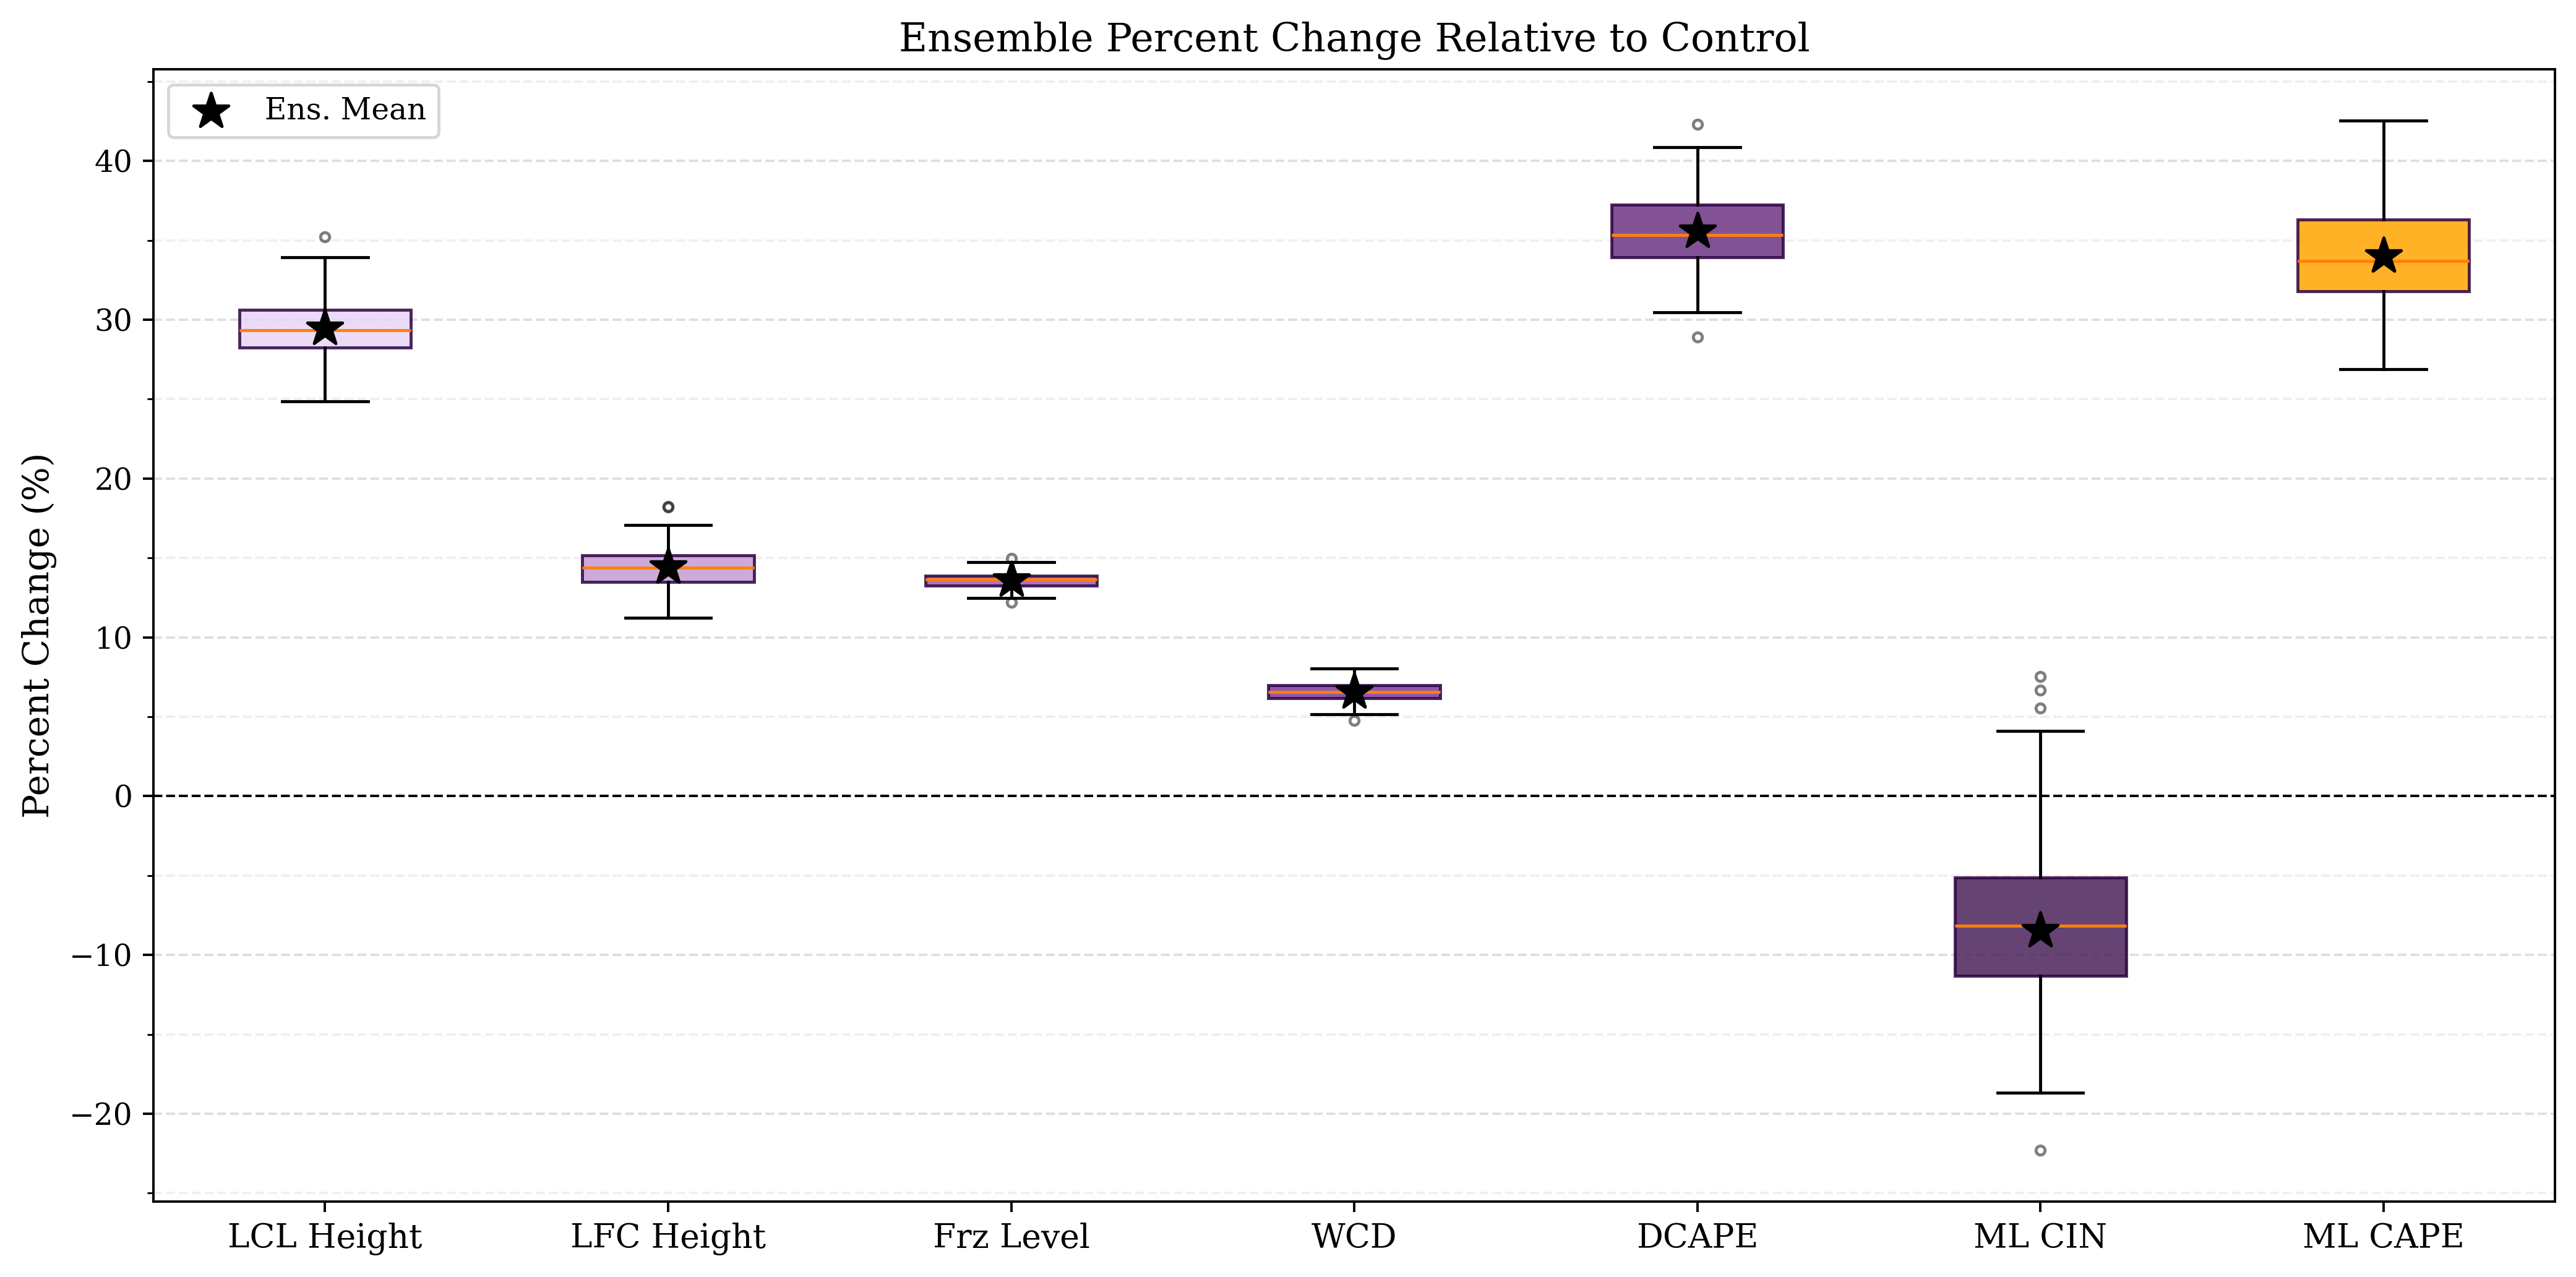

In [39]:
# ---- Data ----
variables = {
    'LCL Height': percent_lcl_mems,
    'LFC Height': percent_lfc_mems,
    'Frz Level':  percent_frz_mems,
    'WCD':        percent_wcd_mems,
    'DCAPE':      percent_dcape_mems,
    'ML CIN':     percent_cin_mems,
    'ML CAPE':    percent_cape_mems,}

means = {
    'LCL Height': percent_lcl_mean,
    'LFC Height': percent_lfc_mean,
    'Frz Level':  percent_frz_mean,
    'WCD':        percent_wcd_mean,
    'DCAPE':      percent_dcape_mean,
    'ML CIN':     percent_cin_mean,
    'ML CAPE':    percent_cape_mean,}

data = []
for key, d in variables.items():
    vals = [v.magnitude if hasattr(v, 'magnitude') else float(v) for v in d.values()]
    data.append(vals)

# ---- Plot ----
colors = ['#E8D5F5', '#C39BD3', '#9B59B6', '#7D3C98', '#6C3483', '#4A235A', 'orange']

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(data, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('#2C0040')
    patch.set_alpha(0.85)

# Overlay ensemble mean as a star
for i, (key, mean_val) in enumerate(means.items()):
    val = mean_val.magnitude if hasattr(mean_val, 'magnitude') else float(mean_val)
    ax.scatter(i + 1, val, marker='*', color='black', s=150, zorder=5,
               label='Ens. Mean' if i == 0 else None)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(range(1, len(variables) + 1))
ax.set_xticklabels(variables.keys(), fontsize=11)
ax.set_ylabel('Percent Change (%)', fontsize=12)
ax.set_title('Ensemble Percent Change Relative to Control', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)
ax.grid(axis='y', which='minor', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

/glade/derecho/scratch/mfranke/tmp/ipykernel_83056/4116100266.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return x.magnitude if hasattr(x, 'magnitude') else float(x)


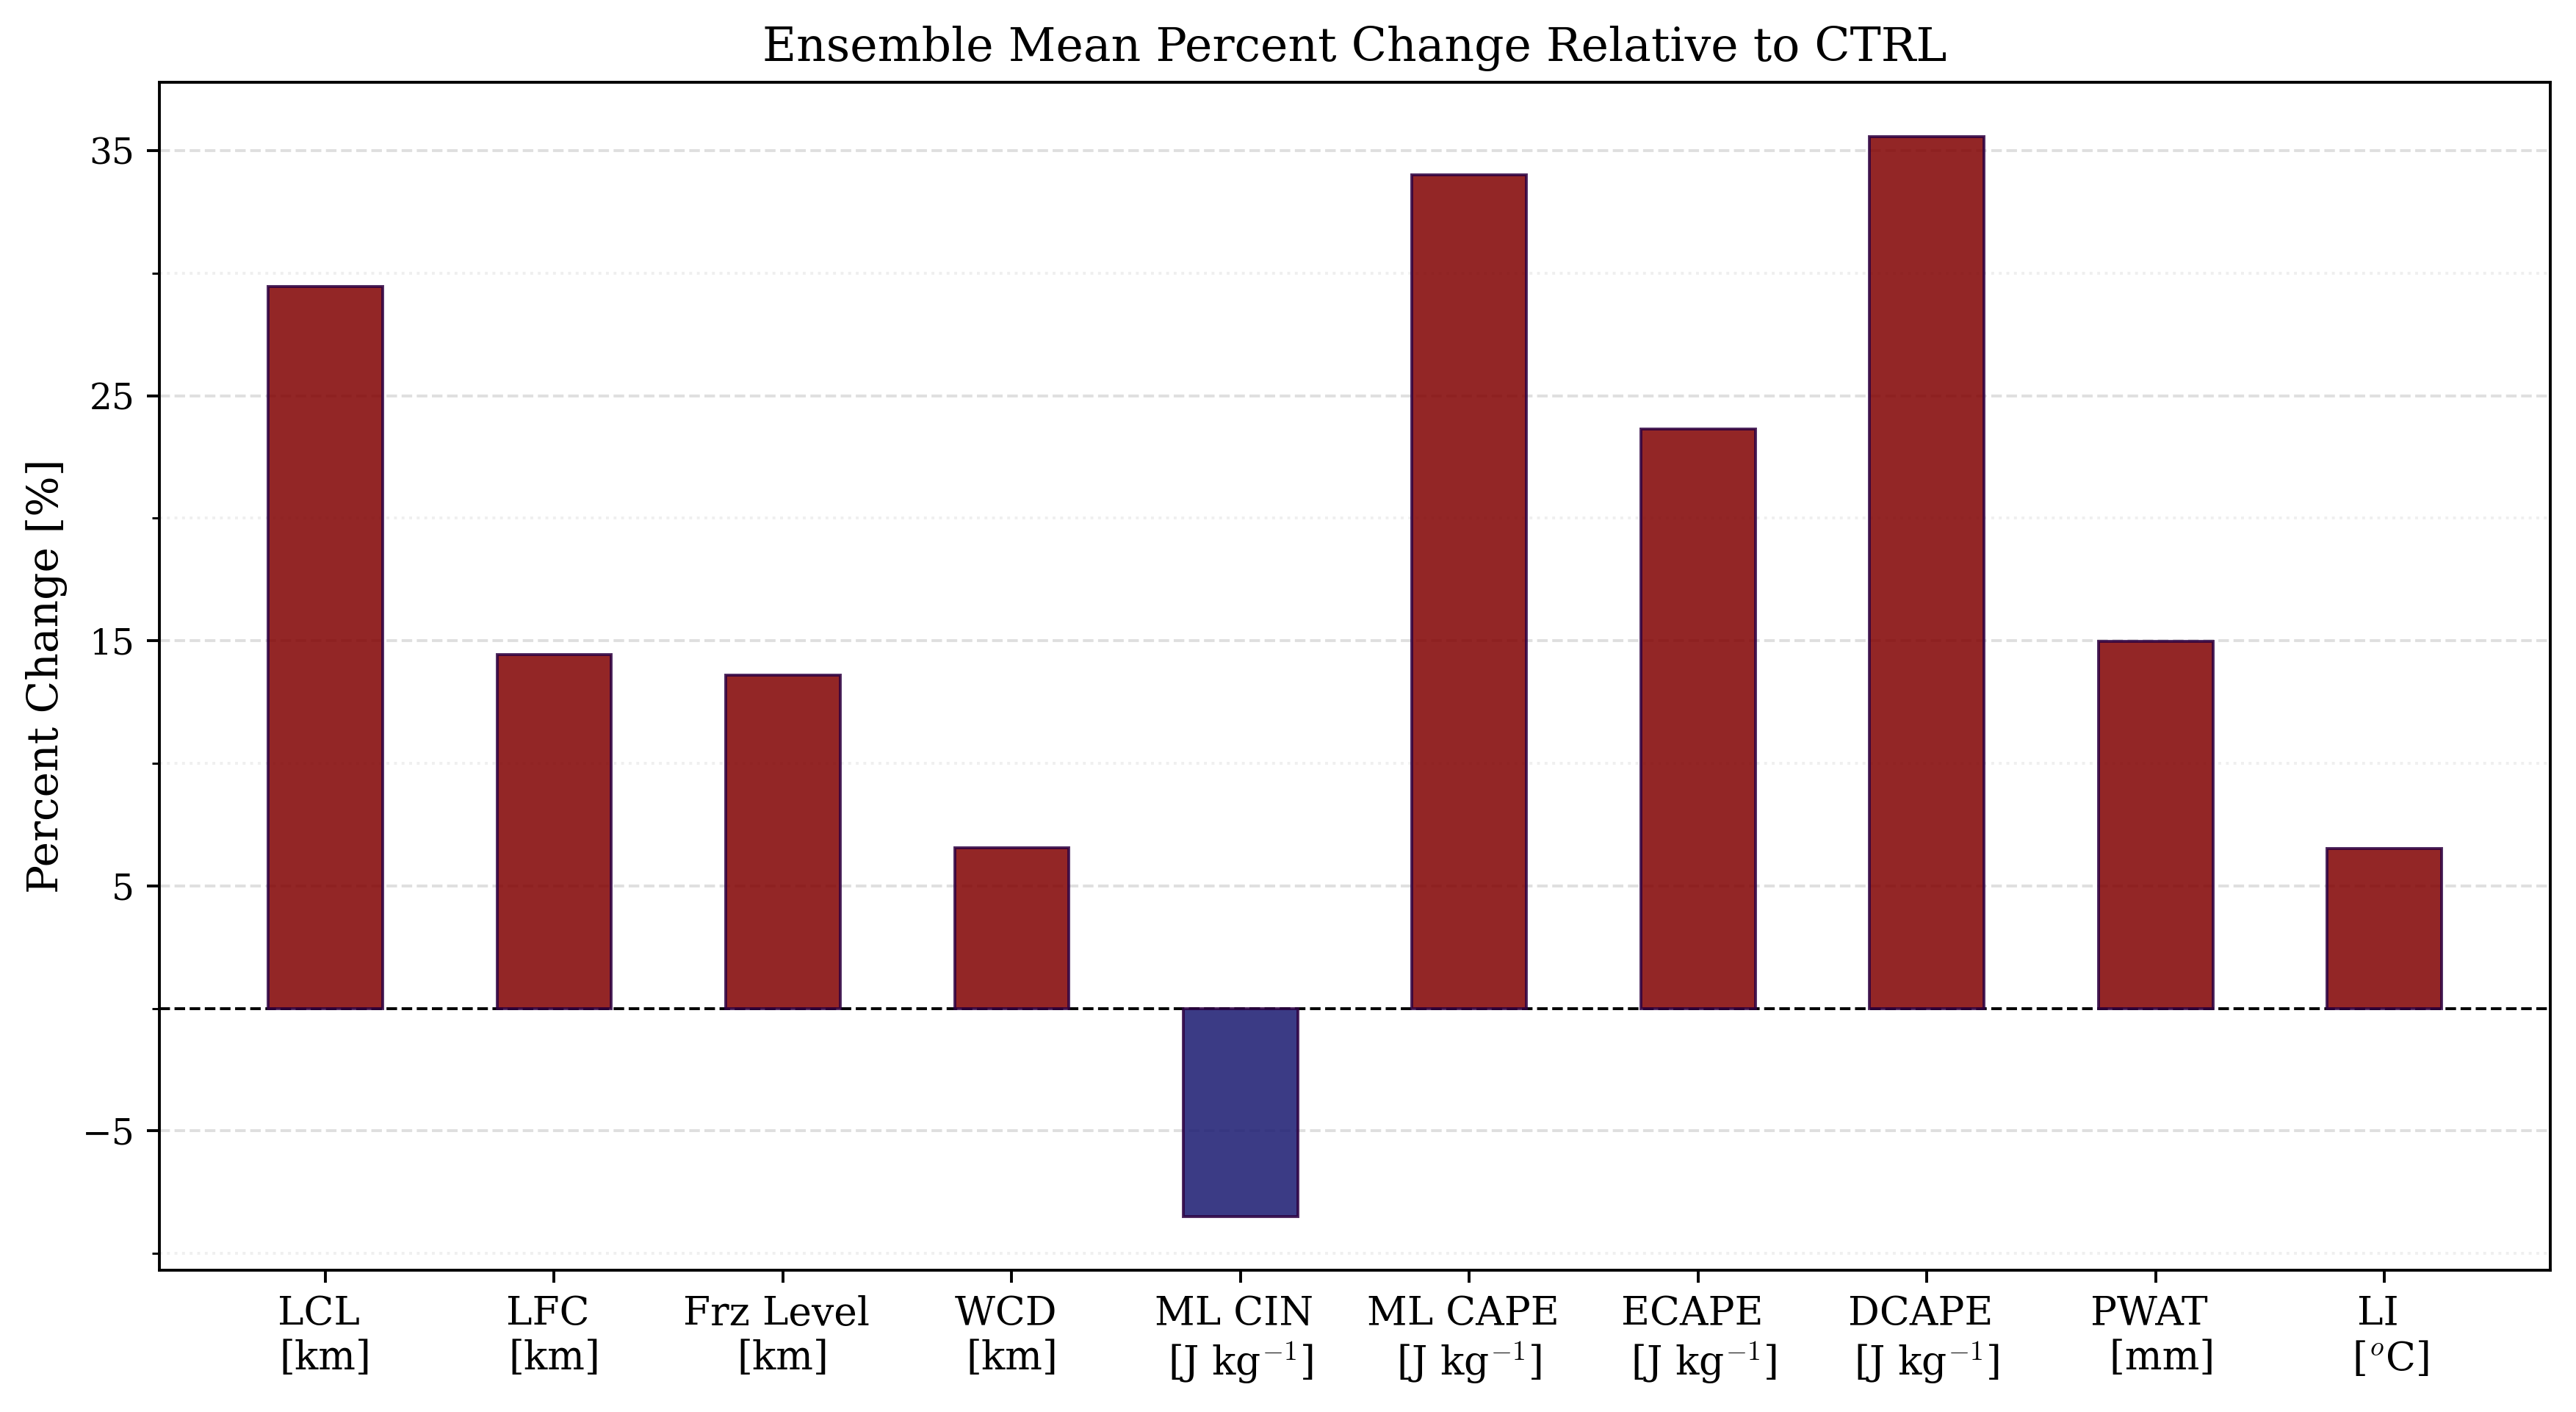

In [40]:
# ---- Data ----
variables = {
    'LCL \n[km]': percent_lcl_mems,
    'LFC \n[km]': percent_lfc_mems,
    'Frz Level \n[km]':  percent_frz_mems,
    'WCD \n[km]':        percent_wcd_mems,
    'ML CIN \n[J kg$^{-1}$]':     percent_cin_mems,
    'ML CAPE \n[J kg$^{-1}$]':    percent_cape_mems,
    'ECAPE \n [J kg$^{-1}$]': percent_ecape_mems,
    'DCAPE \n[J kg$^{-1}$]':      percent_dcape_mems,
    'PWAT \n [mm]': percent_pwat_mean,
    'LI \n [$^{o}$C]' : percent_li_mems
}

means = {
    'LCL \n[km]': percent_lcl_mean,
    'LFC \n[km]': percent_lfc_mean,
    'Frz Level \n[km]':  percent_frz_mean,
    'WCD \n[km]':        percent_wcd_mean,
    'ML CIN \n[J kg$^{-1}$]':     percent_cin_mean,
    'ML CAPE \n[J kg$^{-1}$]':    percent_cape_mean,
    'ECAPE \n [J kg$^{-1}$]': percent_ecape_mean,
    'DCAPE \n[J kg$^{-1}$]':      percent_dcape_mean,
    'PWAT \n [mm]': percent_pwat_mean,
    'LI \n [$^{o}$C]' : percent_li_mean
}

# ---- Helper ----
def to_float(x):
    return x.magnitude if hasattr(x, 'magnitude') else float(x)

# ---- Prep ----
labels = list(variables.keys())
mean_vals = []
spreads = []  # std dev for error bars

for key in labels:
    v = variables[key]

    # FIX: handle scalar vs dict-like structures
    if hasattr(v, "values"):
        vals = [to_float(vv) for vv in v.values()]
    else:
        vals = [to_float(v)]

    m = means[key]

    mean_vals.append(to_float(m))
    spreads.append(np.std(vals))

# ---- Plot ----
colors = ['maroon' if v >= 0 else 'midnightblue' for v in mean_vals]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(labels)) * 0.6  # reduce spacing between bars

bars = ax.bar(x, mean_vals,
              color=colors,
              edgecolor='#2C0040',
              linewidth=0.8,
              alpha=0.85,
              zorder=3,
              width=0.3)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_ylabel('Percent Change [%]', fontsize=12)
ax.set_title('Ensemble Mean Percent Change Relative to CTRL', fontsize=13)

ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))

ax.grid(axis='y', which='major', linestyle='--', alpha=0.4, zorder=0)
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, zorder=0)

ax.set_yticks(np.arange(-5, 41, 10))

# Optional: error bars (you already computed spreads but didn’t plot them)
# ax.errorbar(x, mean_vals, yerr=spreads, fmt='none',
#             ecolor='black', capsize=3, linewidth=1, zorder=4)

# plt.tight_layout()
# plt.savefig('./Figures/percentChangeBars_LENS_CTRL.jpg', dpi=300, bbox_inches='tight')


#### No units on plot: 

/glade/derecho/scratch/mfranke/tmp/ipykernel_83056/3519913449.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return x.magnitude if hasattr(x, 'magnitude') else float(x)


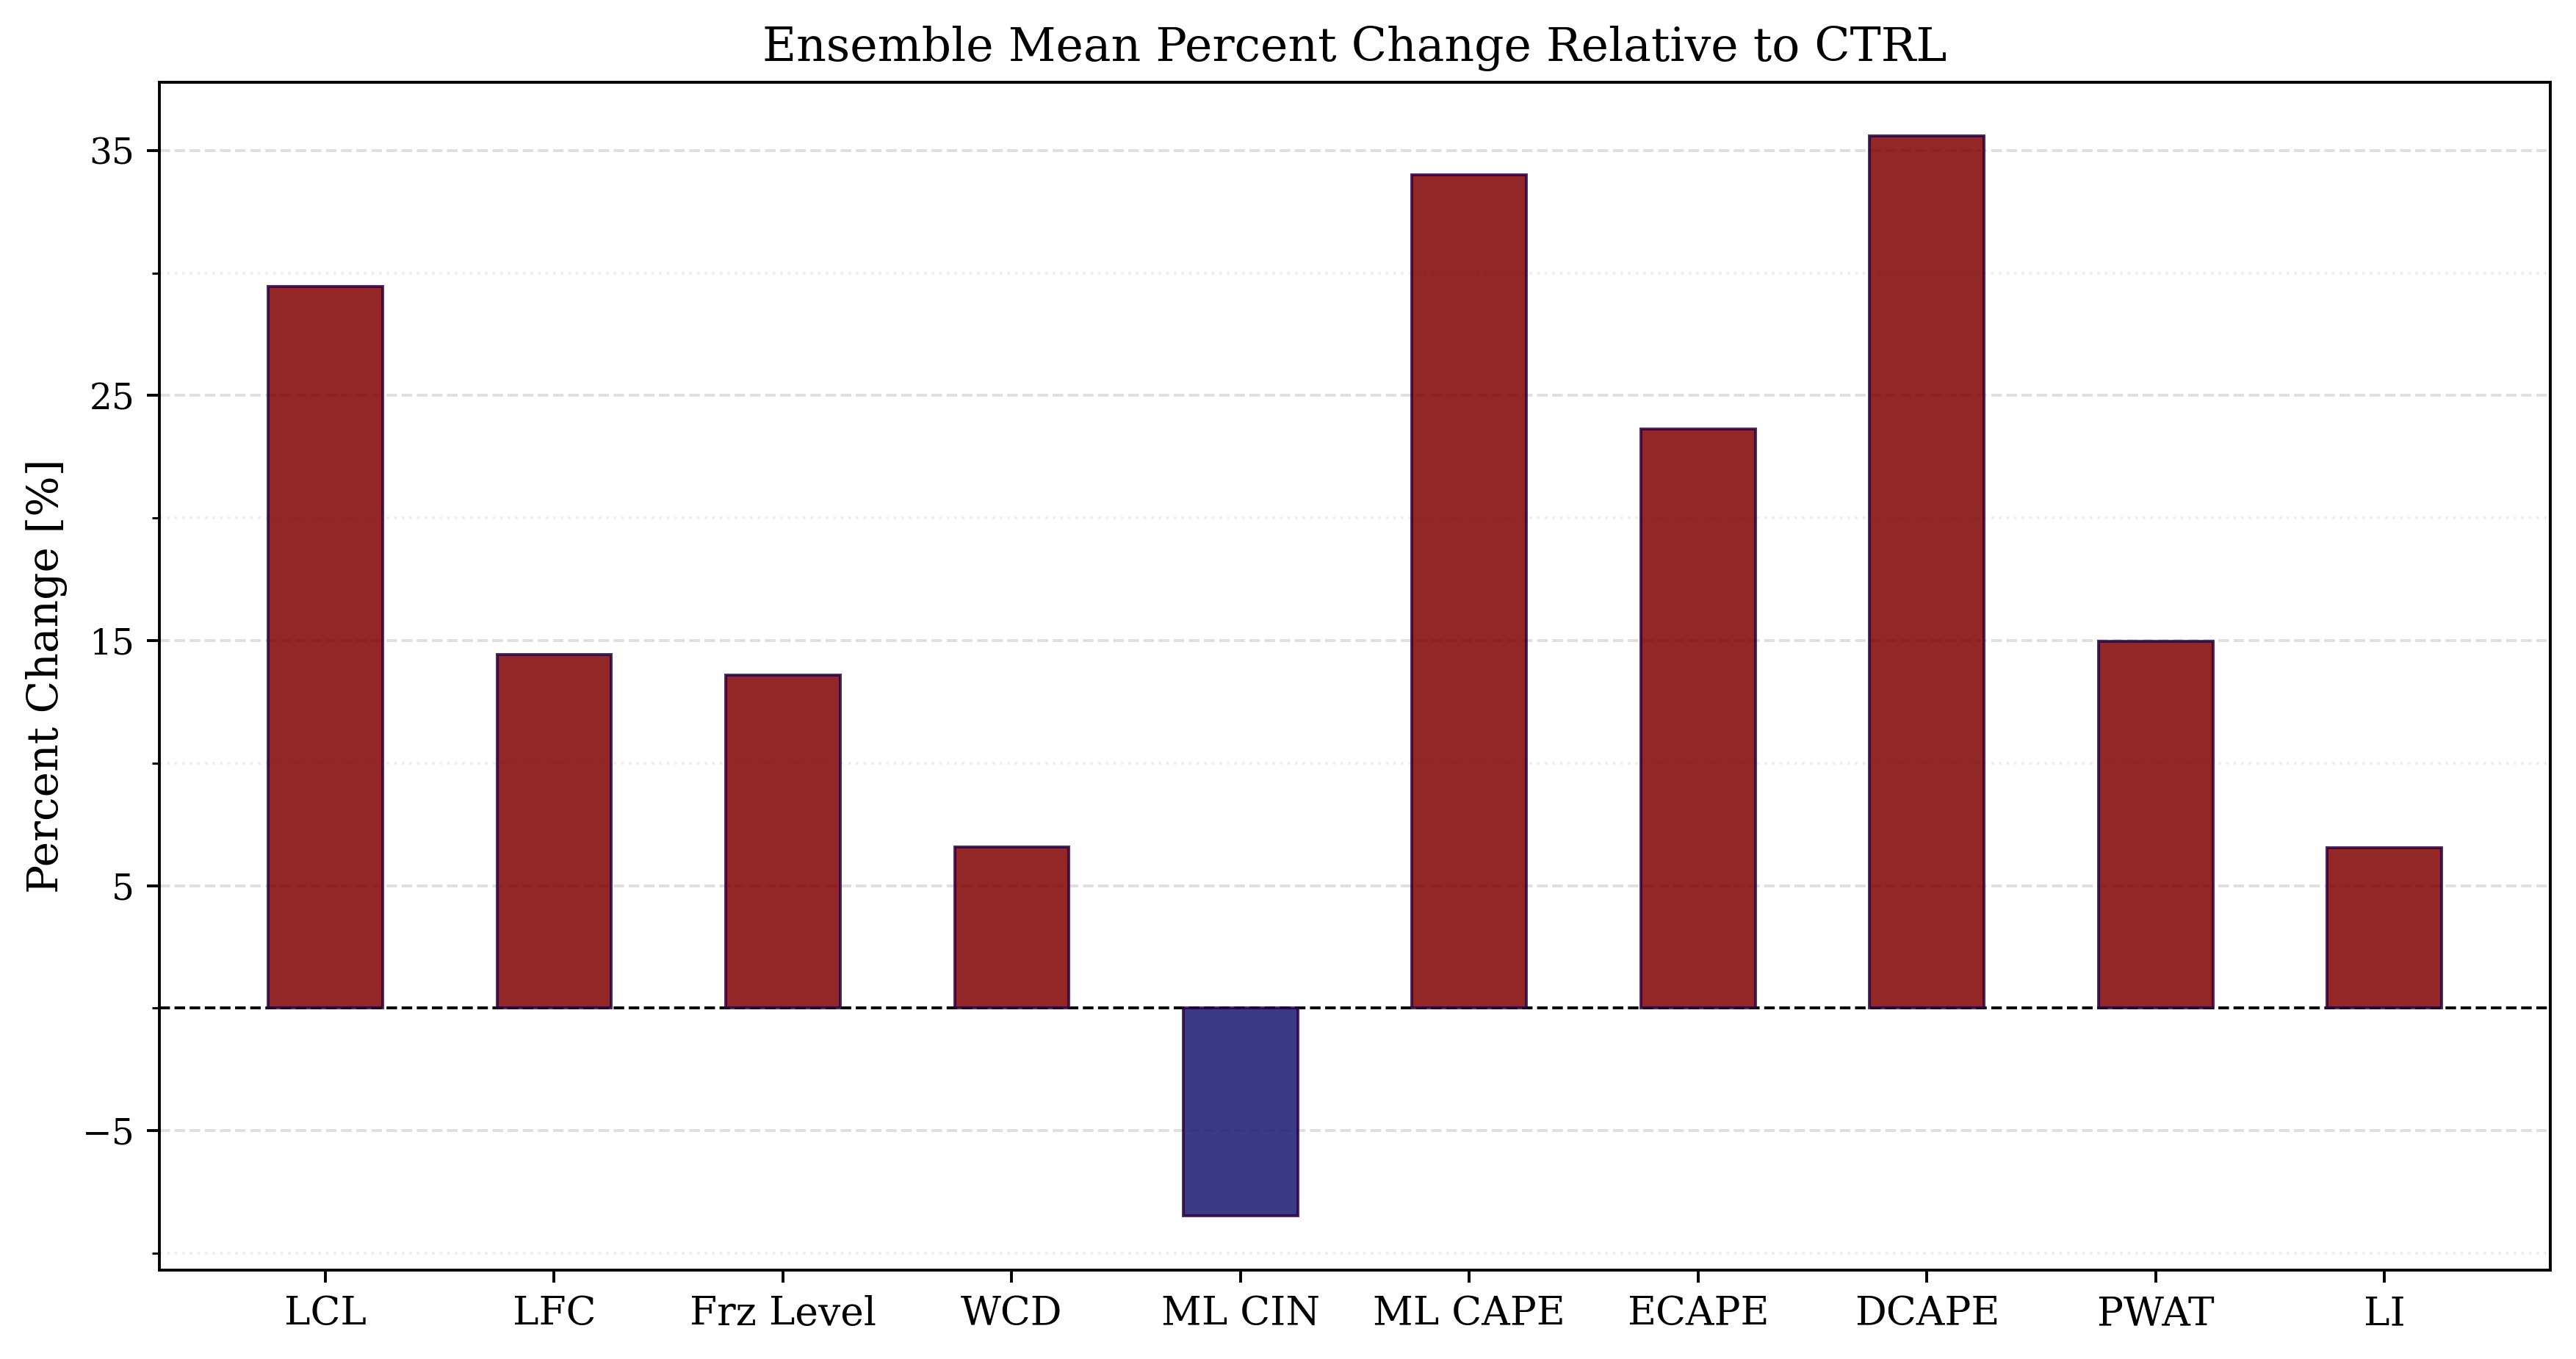

In [41]:
# ---- Data ----
variables = {
    'LCL': percent_lcl_mems,
    'LFC': percent_lfc_mems,
    'Frz Level':  percent_frz_mems,
    'WCD':        percent_wcd_mems,
    'ML CIN':     percent_cin_mems,
    'ML CAPE':    percent_cape_mems,
    'ECAPE': percent_ecape_mems,
    'DCAPE':      percent_dcape_mems,
    'PWAT': percent_pwat_mean,
    'LI' : percent_li_mems
}

means = {
    'LCL': percent_lcl_mean,
    'LFC': percent_lfc_mean,
    'Frz Level':  percent_frz_mean,
    'WCD':        percent_wcd_mean,
    'ML CIN':     percent_cin_mean,
    'ML CAPE':    percent_cape_mean,
    'ECAPE': percent_ecape_mean,
    'DCAPE':      percent_dcape_mean,
    'PWAT': percent_pwat_mean,
    'LI' : percent_li_mean
}

# ---- Helper ----
def to_float(x):
    return x.magnitude if hasattr(x, 'magnitude') else float(x)

# ---- Prep ----
labels = list(variables.keys())
mean_vals = []
spreads = []  # std dev for error bars

for key in labels:
    v = variables[key]

    # FIX: handle scalar vs dict-like structures
    if hasattr(v, "values"):
        vals = [to_float(vv) for vv in v.values()]
    else:
        vals = [to_float(v)]

    m = means[key]

    mean_vals.append(to_float(m))
    spreads.append(np.std(vals))

# ---- Plot ----
colors = ['maroon' if v >= 0 else 'midnightblue' for v in mean_vals]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(labels)) * 0.6  # reduce spacing between bars

bars = ax.bar(x, mean_vals,
              color=colors,
              edgecolor='#2C0040',
              linewidth=0.8,
              alpha=0.85,
              zorder=3,
              width=0.3)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_ylabel('Percent Change [%]', fontsize=12)
ax.set_title('Ensemble Mean Percent Change Relative to CTRL', fontsize=13)

ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))

ax.grid(axis='y', which='major', linestyle='--', alpha=0.4, zorder=0)
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, zorder=0)

ax.set_yticks(np.arange(-5, 41, 10))

# plt.tight_layout()
# plt.savefig('./Figures/percentChangeBars_LENS_CTRL_NoUnits.jpg', dpi=300, bbox_inches='tight')


### Add the CRH to the plot:

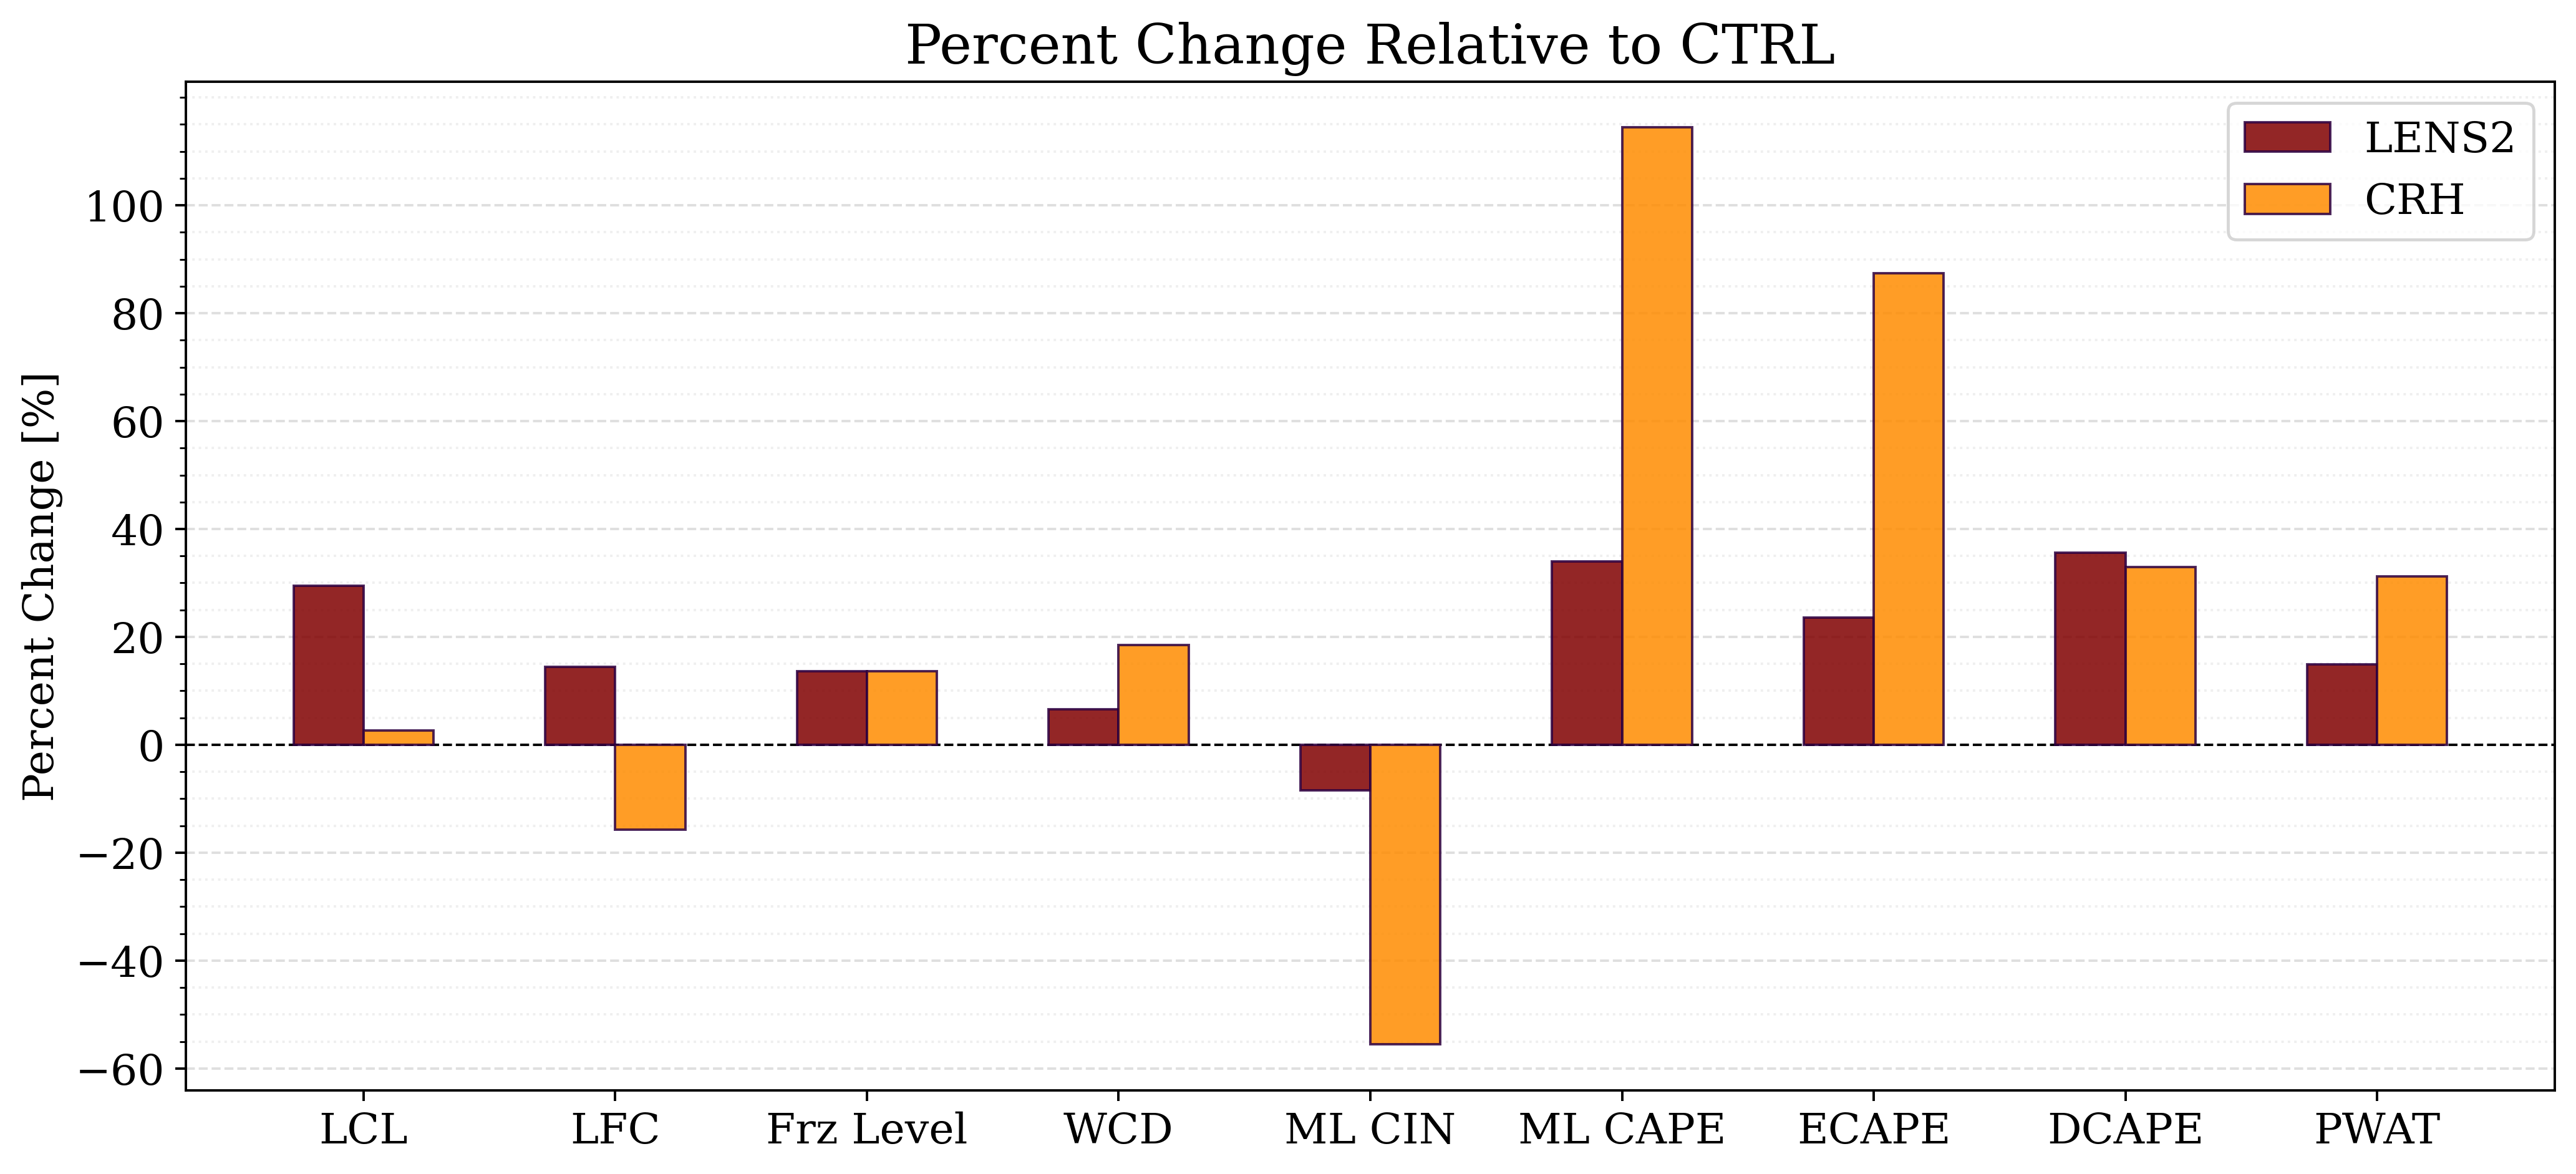

In [57]:
### Set up the data to plot: 
variables = {
    'LCL':       percent_lcl_mems,
    'LFC':       percent_lfc_mems,
    'Frz Level': percent_frz_mems,
    'WCD':       percent_wcd_mems,
    'ML CIN':    percent_cin_mems,
    'ML CAPE':   percent_cape_mems,
    'ECAPE':     percent_ecape_mems,
    'DCAPE':     percent_dcape_mems,
    'PWAT':      percent_pwat_mems}

means = {
    'LCL':       percent_lcl_mean,
    'LFC':       percent_lfc_mean,
    'Frz Level': percent_frz_mean,
    'WCD':       percent_wcd_mean,
    'ML CIN':    percent_cin_mean,
    'ML CAPE':   percent_cape_mean,
    'ECAPE':     percent_ecape_mean,
    'DCAPE':     percent_dcape_mean,
    'PWAT':      percent_pwat_mean}

crh_vals = {
    'LCL':       percent_lcl_crh,
    'LFC':       percent_lfc_crh,
    'Frz Level': percent_frz_crh,
    'WCD':       percent_wcd_crh,
    'ML CIN':    percent_cin_crh,
    'ML CAPE':   percent_cape_crh,
    'ECAPE':     percent_ecape_crh,
    'DCAPE':     percent_dcape_crh,
    'PWAT':      percent_pwat_crh}

### Function to get rid of units, if needed: 
def to_float(x):
    return x.magnitude if hasattr(x, 'magnitude') else float(x)

### Prepare the plot: 
labels = list(variables.keys())
mean_vals = []
crh_mean_vals = []
spreads = []

for key in labels:
    v = variables[key]
    if hasattr(v, "values"):
        vals = [to_float(vv) for vv in v.values()]
    else:
        vals = [to_float(v)]
    mean_vals.append(to_float(means[key]))
    crh_mean_vals.append(to_float(crh_vals[key]))
    spreads.append(np.std(vals))

### Plotting: 
bar_width = 0.25
group_spacing = 0.9  ### Distance between variable groups
x = np.arange(len(labels)) * group_spacing

### Offset so two bars sit symmetrically around each tick
offset_lens = -bar_width / 2
offset_crh  =  bar_width / 2

def bar_color(v, pos_color, neg_color):
    return [pos_color if val >= 0 else neg_color for val in v]

fig, ax = plt.subplots(figsize=(14, 6))

bars_lens = ax.bar(x + offset_lens, mean_vals,
                   width=bar_width,
                   color='maroon',
                   edgecolor='#2C0040',
                   linewidth=0.8,
                   alpha=0.85,
                   zorder=3,
                   label='LENS2')

bars_crh = ax.bar(x + offset_crh, crh_mean_vals,
                  width=bar_width,
                  color='darkorange',
                  edgecolor='#2C0040',
                  linewidth=0.8,
                  alpha=0.85,
                  zorder=3,
                  label='CRH')

### Other plot settings: 
fs_title = 18
fs_axislabel = 14
fs_legend = 14
fs_ticks = 12

##===================
labels = list(variables.keys())
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize = fs_axislabel)
ax.axhline(0, color='k', linestyle='--', linewidth = 0.8)
ax.set_ylabel('Percent Change [%]', fontsize = fs_axislabel)
ax.set_title('Percent Change Relative to CTRL', fontsize = fs_title)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.grid(axis='y', which='major', linestyle='--', alpha=0.4, zorder=0)
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.2, zorder=0)
ax.set_yticks(np.arange(-60, 120, 20))
ax.tick_params(axis='y', labelsize=fs_axislabel)
ax.legend(fontsize=fs_legend)

### Save figure: 
# plt.savefig('./Figures/percentChange_crh_lens.jpg', bbox_inches = 'tight')